# Web Traffic Time Series: Forecasting & Anomaly Detection

**Dataset:** [Kaggle Web Traffic Time Series Forecasting](https://www.kaggle.com/c/web-traffic-time-series-forecasting) (daily views of ~145,000 Wikipedia pages, 2015-07-01 to 2017-09-10.)

**Analysis target:** the *aggregate* daily traffic (sum over all pages), a single clean series with strong weekly seasonality, ideal for decomposition, SARIMA/Prophet, and anomaly detection.

**Workflow**
1. Data preparation & exploration (missing values, ADF, ACF/PACF)
2. Decomposition (classical + STL)
3. Initial forecasting (SARIMA vs Prophet)
4. Anomaly detection (Z-score on STL residuals, ARIMA residuals, Isolation Forest, LSTM autoencoder)
5. Re-forecasting after anomaly cleaning & before/after comparison


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
np.random.seed(42)
os.makedirs('figs', exist_ok=True)

/sessions/relaxed-magical-maxwell/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Data preparation

The raw file (`train_2.csv`, ~400 MB) holds one row per page and one column per day. We aggregate to total daily views in chunks. The result is cached to `data/daily_total.csv` so subsequent runs are instant.

In [2]:
CACHE = 'data/daily_total.csv'
RAW = 'train_2.csv/train_2.csv'  # as extracted from Kaggle

if os.path.exists(CACHE):
    df = pd.read_csv(CACHE, parse_dates=['date']).set_index('date').asfreq('D')
    print('Loaded cached aggregate.')
else:
    total, miss, n = None, None, 0
    for chunk in pd.read_csv(RAW, chunksize=20000):
        vals = chunk.drop(columns=['Page'])
        s_, m_ = vals.sum(axis=0, skipna=True), vals.isna().sum(axis=0)
        total = s_ if total is None else total + s_
        miss = m_ if miss is None else miss + m_
        n += len(chunk)
    df = pd.DataFrame({'date': pd.to_datetime(total.index),
                       'views': total.values, 'missing_pages': miss.values}).set_index('date').asfreq('D')
    os.makedirs('data', exist_ok=True)
    df.to_csv(CACHE)
    print(f'Aggregated {n:,} pages.')

s = df['views'] / 1e6  # work in millions of views
print(f'{len(s)} days: {s.index.min().date()} -> {s.index.max().date()}')
print(f'Days with NaN after aggregation: {s.isna().sum()}')

Loaded cached aggregate.
803 days: 2015-07-01 -> 2017-09-10
Days with NaN after aggregation: 0


**Missing values.** Individual pages have many missing days (page not yet created / no data), but after summation the aggregate series has **no missing days** — `skipna=True` treats page-level gaps as zero contribution. No imputation is needed at the aggregate level. The `missing_pages` column tracks how many pages were missing each day (it declines over time as pages come online).

## 2. Exploration

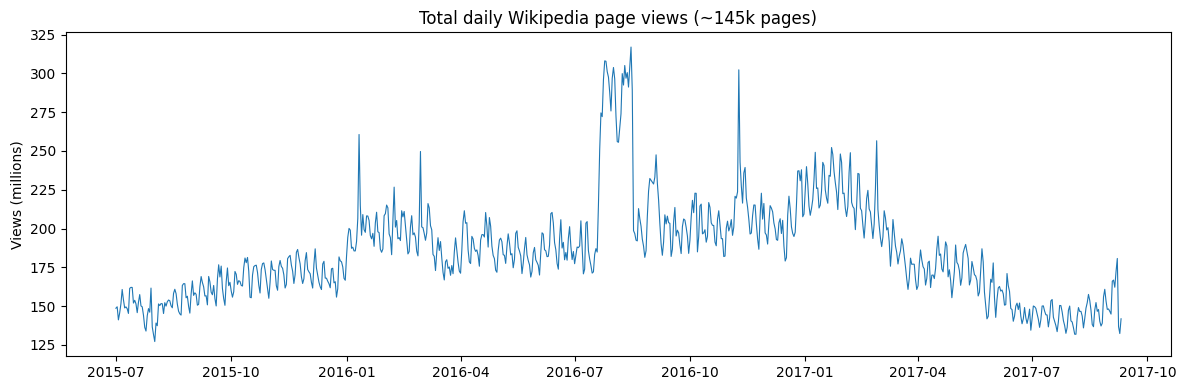

mean 185.5M | min 127.2M on 2015-08-01 | max 316.9M on 2016-08-15


In [3]:
fig, ax = plt.subplots()
ax.plot(s, lw=0.8)
ax.set_title('Total daily Wikipedia page views (~145k pages)')
ax.set_ylabel('Views (millions)')
plt.tight_layout(); plt.savefig('figs/01_series.png', dpi=120); plt.show()

print(f'mean {s.mean():.1f}M | min {s.min():.1f}M on {s.idxmin().date()} | max {s.max():.1f}M on {s.idxmax().date()}')

Visible features: a mild upward drift through 2016, a striking high-activity regime in **Jul–Aug 2016** (Rio Olympics, US election campaign, Pokémon GO), isolated spikes, and clear short-period oscillation — the weekly cycle.

### Stationarity (ADF test)

In [4]:
for name, x in [('raw series', s), ('1st difference', s.diff().dropna())]:
    stat, p, lags, *_ = adfuller(x, autolag='AIC')
    print(f'{name:15s}  ADF={stat:7.3f}  p-value={p:.4g}  ->', 'stationary' if p < 0.05 else 'NON-stationary')

raw series       ADF= -2.655  p-value=0.08224  -> NON-stationary
1st difference   ADF= -5.485  p-value=2.235e-06  -> stationary


The raw series fails to reject the unit-root null at 5% (p ≈ 0.08) **non-stationary**, consistent with the visible drift. The first difference is clearly stationary (p ≈ 2e-6), so **d = 1** for ARIMA modelling.

### ACF / PACF

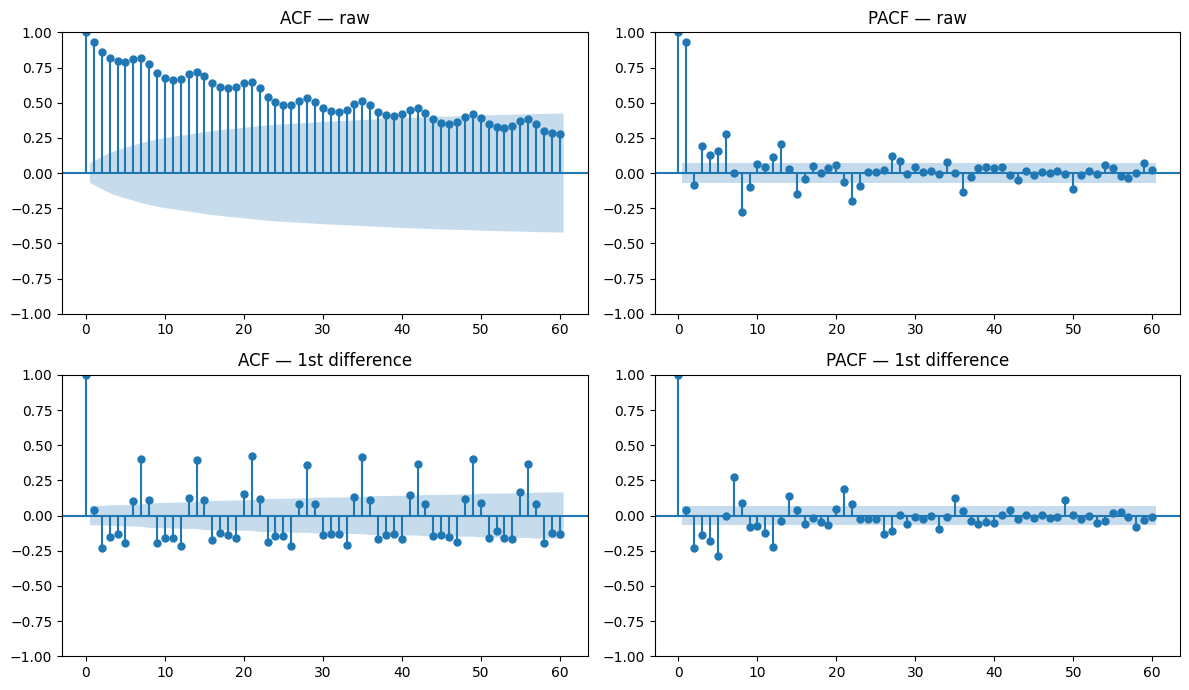

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(s, lags=60, ax=axes[0,0], title='ACF — raw')
plot_pacf(s, lags=60, ax=axes[0,1], method='ywm', title='PACF — raw')
plot_acf(s.diff().dropna(), lags=60, ax=axes[1,0], title='ACF — 1st difference')
plot_pacf(s.diff().dropna(), lags=60, ax=axes[1,1], method='ywm', title='PACF — 1st difference')
plt.tight_layout(); plt.savefig('figs/02_acf_pacf.png', dpi=120); plt.show()

The differenced ACF shows sharp spikes at lags **7, 14, 21, ...** : weekly seasonality. This shows a **seasonal** ARIMA with period m = 7.

## 3. Decomposition (classical + STL)

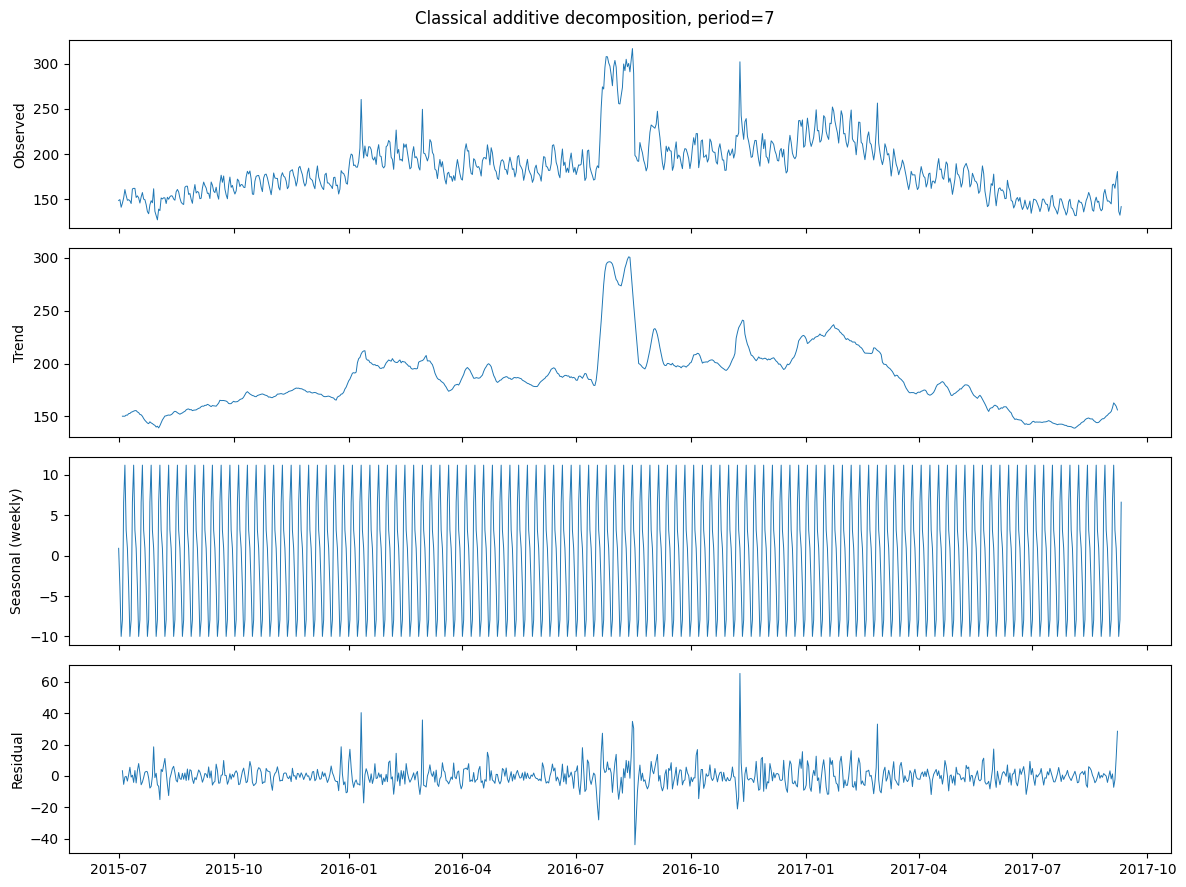

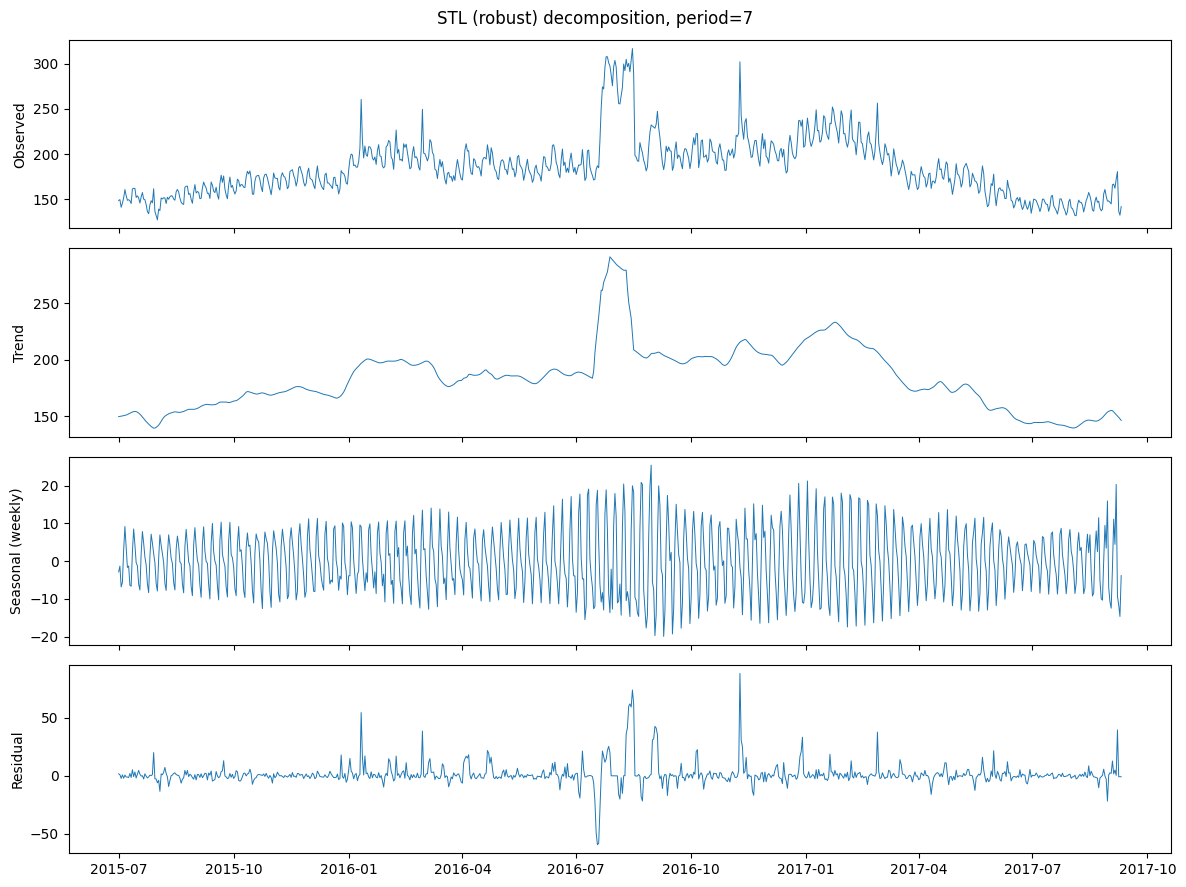

In [6]:
dec_c = seasonal_decompose(s, model='additive', period=7)
stl = STL(s, period=7, robust=True).fit()

for name, dec in [('Classical additive', dec_c), ('STL (robust)', stl)]:
    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    for ax, comp, t in zip(axes, [dec.observed, dec.trend, dec.seasonal, dec.resid],
                           ['Observed', 'Trend', 'Seasonal (weekly)', 'Residual']):
        ax.plot(comp, lw=0.7); ax.set_ylabel(t)
    fig.suptitle(f'{name} decomposition, period=7')
    plt.tight_layout()
    plt.savefig(f"figs/03_decomp_{'classical' if 'Class' in name else 'stl'}.png", dpi=120)
    plt.show()

In [7]:
# Strength of components (Hyndman & Athanasopoulos)
Ft = max(0, 1 - np.var(stl.resid) / np.var(stl.trend + stl.resid))
Fs = max(0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
print(f'Trend strength: {Ft:.2f} | Seasonal strength: {Fs:.2f}')
wk = stl.seasonal.groupby(stl.seasonal.index.dayofweek).mean()
print('Mean weekly effect (Mon..Sun, millions):', wk.round(1).tolist())

Trend strength: 0.90 | Seasonal strength: 0.37
Mean weekly effect (Mon..Sun, millions): [11.4, 4.4, -0.3, -4.5, -10.2, -7.8, 7.0]


**Interpretation.**
- **Trend** (strength ≈ 0.90): traffic rises from ~150M/day in mid-2015 to a peak around the 2016 US election, then settles around 180–200M.
- **Seasonality** (strength ≈ 0.37): a stable weekly cycle, **Mondays are the busiest** (+11M vs. average) and **Fridays the quietest** (−10M), a classic work week browsing pattern.
- **Residuals**: mostly noise (σ ≈ 10M), but with large isolated excursions — exactly the anomalies we hunt in section 5. STL's robust fitting keeps these spikes in the residual instead of leaking them into the trend, which is why we prefer STL residuals for anomaly detection.

## 4. Initial forecasting — SARIMA vs Prophet

Holdout: the **last 60 days** (2017-07-13 → 2017-09-10). Models see only the training portion.

In [8]:
train, test = s[:-60], s[-60:]
print(f'train: {len(train)} days | test: {len(test)} days ({test.index.min().date()} -> {test.index.max().date()})')

# Small grid search over SARIMA orders by AIC
grid = []
for order in [(1,1,1), (2,1,1), (1,1,2), (2,1,2), (0,1,1)]:
    for sorder in [(1,1,1,7), (0,1,1,7), (1,0,1,7)]:
        try:
            m = SARIMAX(train, order=order, seasonal_order=sorder,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            grid.append((m.aic, order, sorder))
        except Exception:
            pass
grid.sort()
print('Top 5 by AIC:')
for aic, o, so in grid[:5]:
    print(f'  SARIMA{o}x{so}  AIC={aic:.1f}')
best_order, best_sorder = grid[0][1], grid[0][2]

train: 743 days | test: 60 days (2017-07-13 -> 2017-09-10)


Top 5 by AIC:
  SARIMA(1, 1, 2)x(0, 1, 1, 7)  AIC=5316.9
  SARIMA(2, 1, 2)x(0, 1, 1, 7)  AIC=5318.1
  SARIMA(1, 1, 2)x(1, 1, 1, 7)  AIC=5318.9
  SARIMA(2, 1, 2)x(1, 1, 1, 7)  AIC=5320.1
  SARIMA(1, 1, 1)x(0, 1, 1, 7)  AIC=5323.7


In [9]:
sarima = SARIMAX(train, order=best_order, seasonal_order=best_sorder,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc = sarima.get_forecast(60)
sar_pred, ci = fc.predicted_mean, fc.conf_int()

pdf = train.reset_index(); pdf.columns = ['ds', 'y']
prophet = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet.fit(pdf)
pro_pred = prophet.predict(prophet.make_future_dataframe(60)).set_index('ds')['yhat'][-60:]

def metrics(y, yhat):
    return {'RMSE': round(float(np.sqrt(mean_squared_error(y, yhat))), 2),
            'MAE': round(float(mean_absolute_error(y, yhat)), 2)}

before = {'SARIMA': metrics(test, sar_pred) | {'AIC': round(sarima.aic, 1), 'BIC': round(sarima.bic, 1)},
          'Prophet': metrics(test, pro_pred)}
pd.DataFrame(before).T

16:36:57 - cmdstanpy - INFO - Chain [1] start processing


16:36:57 - cmdstanpy - INFO - Chain [1] done processing


,RMSE,MAE,AIC,BIC
SARIMA,12.65,8.53,5316.9,5339.9
Prophet,38.11,32.38,NaN,NaN


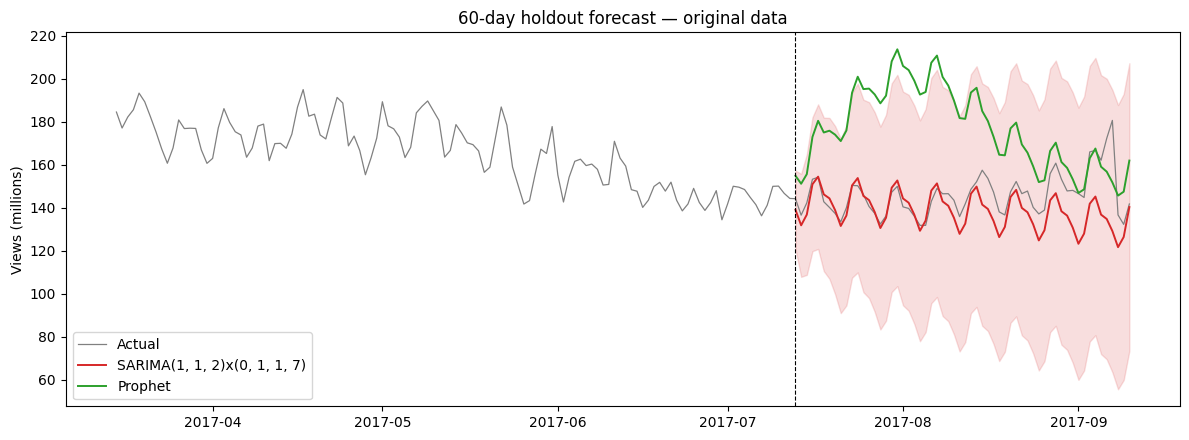

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s[-180:], lw=0.9, color='gray', label='Actual')
ax.plot(sar_pred, lw=1.4, color='#d62728', label=f'SARIMA{best_order}x{best_sorder}')
ax.plot(pro_pred, lw=1.4, color='#2ca02c', label='Prophet')
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.15, color='#d62728')
ax.axvline(test.index[0], ls='--', color='k', lw=0.8)
ax.set_title('60-day holdout forecast — original data'); ax.set_ylabel('Views (millions)'); ax.legend()
plt.tight_layout(); plt.savefig('figs/04_forecast_before.png', dpi=120); plt.show()

**SARIMA wins decisively** (RMSE ≈ 12.7M vs ≈ 38M for Prophet). Prophet extrapolates a yearly-seasonality + trend curve that was distorted by the anomalous mid-2016 regime, so it overshoots the stable 2017 traffic. SARIMA's differencing anchors it to the recent level.

## 5. Anomaly detection — four methods

1. **Robust Z-score on STL residuals** (statistical): MAD-based z on the deseasonalised, detrended residual; |z| > 3.5.
2. **SARIMA residuals** (statistical): standardized one-step-ahead prediction errors; |z| > 3.
3. **Isolation Forest** (ML): on features [level, Δ1, Δ7, STL residual, day-of-week], contamination 2%.
4. **LSTM autoencoder** (DL, optional): reconstruction error on 14-day windows; error > μ + 3σ.

In [11]:
# --- 1) Robust Z-score on STL residuals
r = stl.resid
z = (r - r.median()) / (1.4826 * np.abs(r - r.median()).median())
a_z = np.abs(z) > 3.5

# --- 2) SARIMA residuals (model fit on full series)
m_full = SARIMAX(s, order=best_order, seasonal_order=best_sorder,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sr = pd.Series(m_full.standardized_forecasts_error[0], index=s.index)
sr[:14] = 0  # burn-in
a_ar = np.abs(sr) > 3

# --- 3) Isolation Forest
X = pd.DataFrame({'views': s, 'diff': s.diff(), 'diff7': s.diff(7),
                  'resid': r, 'dow': s.index.dayofweek}).fillna(0)
a_if = pd.Series(IsolationForest(contamination=0.02, random_state=42).fit_predict(X) == -1, index=s.index)

print(f'Z-score: {a_z.sum()} | SARIMA resid: {a_ar.sum()} | Isolation Forest: {a_if.sum()}')

Z-score: 99 | SARIMA resid: 13 | Isolation Forest: 17


In [12]:
# --- 4) LSTM autoencoder (optional DL method)
import tensorflow as tf
tf.random.set_seed(42)

x_std = ((s - s.mean()) / s.std()).values
W = 14
Xw = np.array([x_std[i:i+W] for i in range(len(x_std) - W + 1)])[..., None]

ae = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(W, 1)),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.RepeatVector(W),
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
])
ae.compile(optimizer='adam', loss='mae')
ae.fit(Xw, Xw, epochs=30, batch_size=32, verbose=0)

err = np.abs(ae.predict(Xw, verbose=0) - Xw).squeeze()
day_err, cnt = np.zeros(len(x_std)), np.zeros(len(x_std))
for i in range(len(Xw)):
    day_err[i:i+W] += err[i]; cnt[i:i+W] += 1
de = pd.Series(day_err / cnt, index=s.index)
a_ae = de > de.mean() + 3 * de.std()
print(f'LSTM-AE: {a_ae.sum()} anomalies')

I0000 00:00:1783003019.978820       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783003020.026968       9 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783003021.559269       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


E0000 00:00:1783003024.213302       9 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


LSTM-AE: 8 anomalies


In [13]:
anoms = pd.DataFrame({'zscore': a_z, 'arima_resid': a_ar, 'iso_forest': a_if, 'lstm_ae': a_ae})
anoms['n_methods'] = anoms.sum(axis=1)
cons = anoms.index[anoms['n_methods'] >= 2]
print(f'Consensus (flagged by >=2 methods): {len(cons)} days')
anoms.loc[cons].assign(views=s[cons].round(1)).sort_values('n_methods', ascending=False)

Consensus (flagged by >=2 methods): 20 days


,zscore,arima_resid,iso_forest,lstm_ae,n_methods,views
date,,,,,,
2016-01-11,True,True,True,True,4,260.6
2016-02-29,True,True,True,True,4,249.7
2016-11-09,True,True,True,True,4,302.3
2016-07-22,True,True,True,False,3,274.5
2016-08-16,True,False,True,True,3,289.1
2017-02-27,True,False,True,True,3,256.6
2016-11-10,True,True,True,False,3,242.9
2016-08-17,False,True,True,True,3,198.6
2016-08-15,True,False,True,True,3,316.9


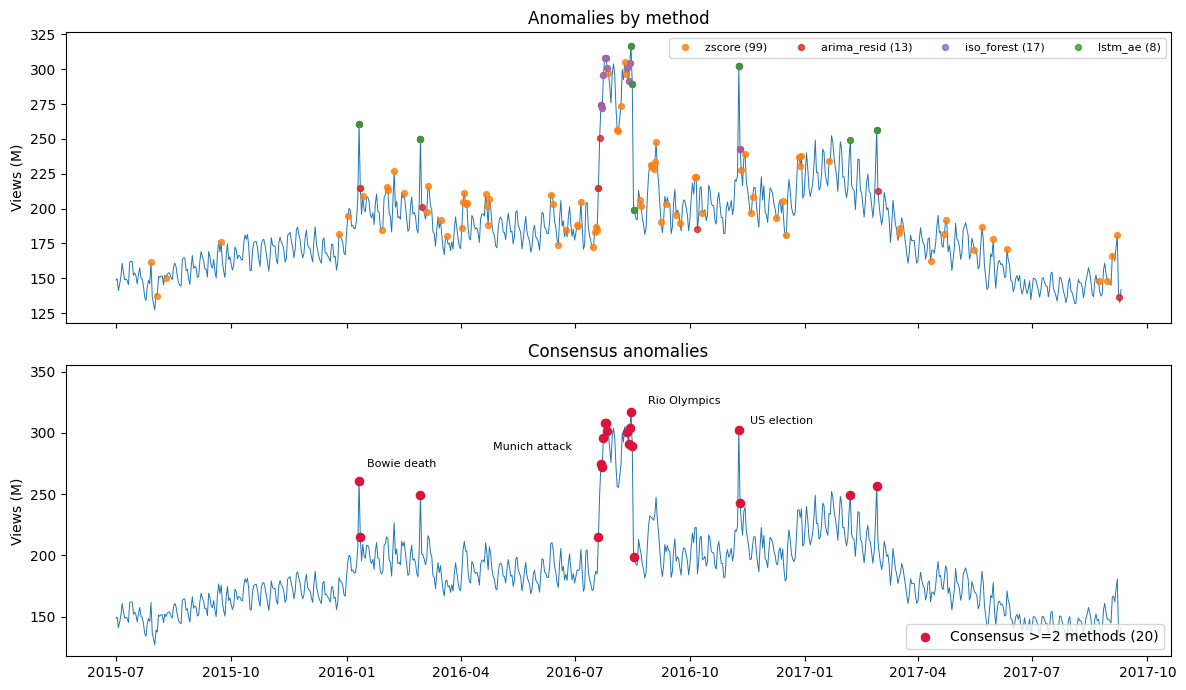

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(s, lw=0.7)
for m_, c in [('zscore', '#ff7f0e'), ('arima_resid', '#d62728'), ('iso_forest', '#9467bd'), ('lstm_ae', '#2ca02c')]:
    idx = anoms.index[anoms[m_]]
    axes[0].scatter(idx, s[idx], s=18, color=c, label=f'{m_} ({anoms[m_].sum()})', zorder=3, alpha=0.8)
axes[0].legend(ncol=4, fontsize=8); axes[0].set_title('Anomalies by method'); axes[0].set_ylabel('Views (M)')

axes[1].plot(s, lw=0.7)
axes[1].scatter(cons, s[cons], s=35, color='crimson', zorder=3, label=f'Consensus >=2 methods ({len(cons)})')
axes[1].set_ylim(top=s.max() * 1.12)
for d, lbl, off in [('2016-01-11', 'Bowie death', (6, 10)), ('2016-11-09', 'US election', (8, 4)),
                    ('2016-08-15', 'Rio Olympics', (12, 6)), ('2016-07-22', 'Munich attack', (-78, 10))]:
    d = pd.Timestamp(d)
    axes[1].annotate(lbl, (d, s[d]), textcoords='offset points', xytext=off, fontsize=8)
axes[1].legend(loc='lower right'); axes[1].set_ylabel('Views (M)'); axes[1].set_title('Consensus anomalies')
plt.tight_layout(); plt.savefig('figs/05_anomalies.png', dpi=120); plt.show()

**The consensus anomalies map onto real-world events:**

| Date(s) | Event |
|---|---|
| 2016-01-11/12 | Death of David Bowie |
| 2016-02-29 | Leap day |
| 2016-07-20 – 2016-08-17 | Munich attack, DNC, Rio Olympics — sustained high-traffic regime (all-time peak, 317M on Aug 15) |
| 2016-11-09/10 | US presidential election result (302M views) |
| 2017-02-06 / 2017-02-27 | Super Bowl LI / Oscars Best-Picture mix-up |

**Impact:** these one-off spikes inflate variance estimates, widen prediction intervals, and for global-fit models, distort the estimated trend and yearly seasonality.

## 6. Re-forecasting after anomaly cleaning

We impute the 20 consensus anomalies with the **median of the same weekday within ±4 weeks** (preserving the weekly cycle), then refit both models. Evaluation is still against the **original, uncleaned** test data ,real future traffic is what we ultimately need to predict, and all anomalies fall before the test window.

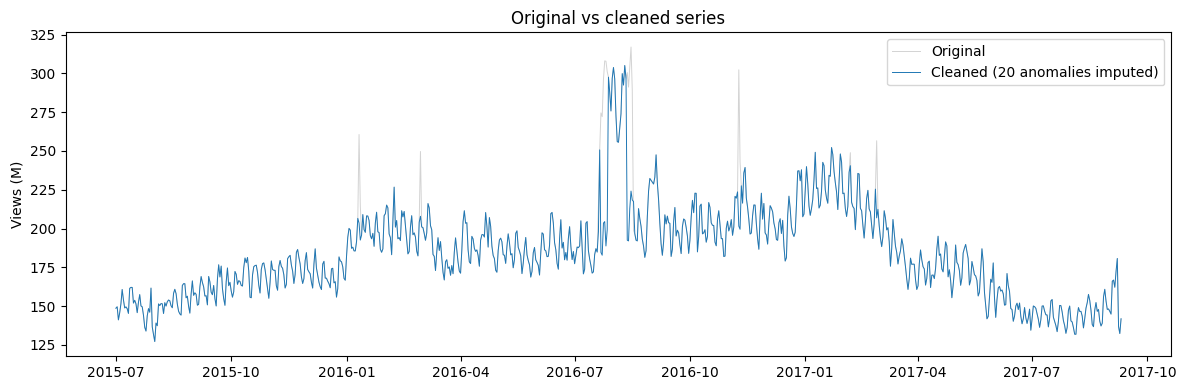

In [15]:
sc = s.copy()
for d in cons:
    same = s[(s.index.dayofweek == d.dayofweek) & (~s.index.isin(cons))]
    sc[d] = same[abs((same.index - d).days) <= 28].median()

fig, ax = plt.subplots()
ax.plot(s, lw=0.7, color='lightgray', label='Original')
ax.plot(sc, lw=0.7, label=f'Cleaned ({len(cons)} anomalies imputed)')
ax.legend(); ax.set_ylabel('Views (M)'); ax.set_title('Original vs cleaned series')
plt.tight_layout(); plt.savefig('figs/07_cleaned.png', dpi=120); plt.show()

In [16]:
train_c = sc[:-60]

sarima_c = SARIMAX(train_c, order=best_order, seasonal_order=best_sorder,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sar_pred_c = sarima_c.get_forecast(60).predicted_mean

pdf_c = train_c.reset_index(); pdf_c.columns = ['ds', 'y']
prophet_c = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_c.fit(pdf_c)
pro_pred_c = prophet_c.predict(prophet_c.make_future_dataframe(60)).set_index('ds')['yhat'][-60:]

after = {'SARIMA': metrics(test, sar_pred_c) | {'AIC': round(sarima_c.aic, 1), 'BIC': round(sarima_c.bic, 1)},
         'Prophet': metrics(test, pro_pred_c)}

comp = pd.concat({'before cleaning': pd.DataFrame(before).T, 'after cleaning': pd.DataFrame(after).T}, axis=1)
comp

16:37:13 - cmdstanpy - INFO - Chain [1] start processing


16:37:13 - cmdstanpy - INFO - Chain [1] done processing


before cleaning                        after cleaning                 \
                   RMSE    MAE     AIC     BIC           RMSE    MAE     AIC   
SARIMA            12.65   8.53  5316.9  5339.9          16.06  11.68  5268.4   
Prophet           38.11  32.38     NaN     NaN          22.16  17.81     NaN   

                 
            BIC  
SARIMA   5291.4  
Prophet     NaN

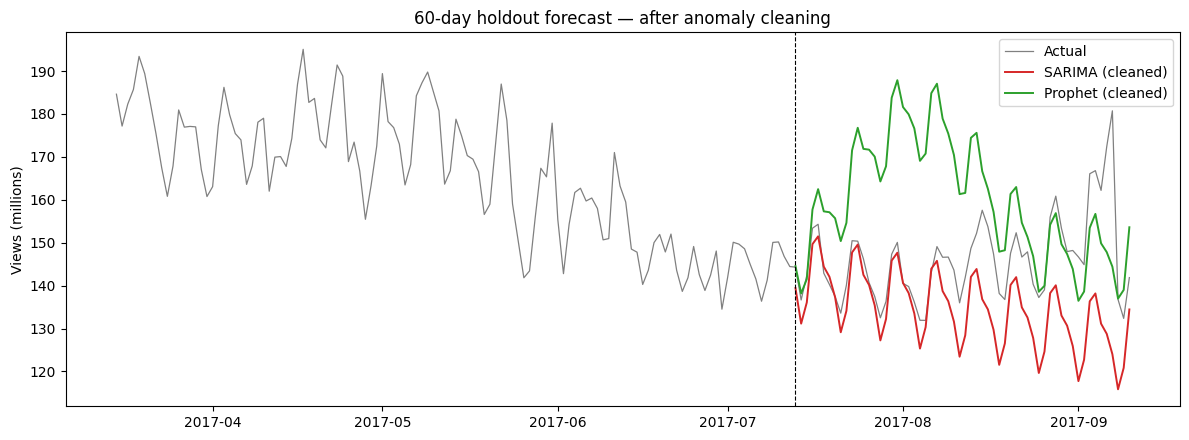

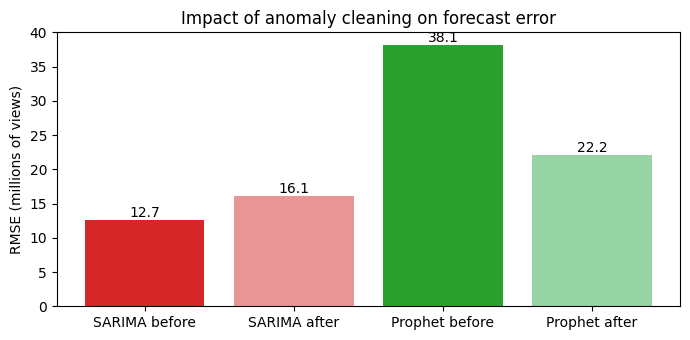

In [17]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s[-180:], lw=0.9, color='gray', label='Actual')
ax.plot(sar_pred_c, lw=1.4, color='#d62728', label='SARIMA (cleaned)')
ax.plot(pro_pred_c, lw=1.4, color='#2ca02c', label='Prophet (cleaned)')
ax.axvline(test.index[0], ls='--', color='k', lw=0.8)
ax.set_title('60-day holdout forecast — after anomaly cleaning'); ax.set_ylabel('Views (millions)'); ax.legend()
plt.tight_layout(); plt.savefig('figs/06_forecast_after.png', dpi=120); plt.show()

labels = ['SARIMA before', 'SARIMA after', 'Prophet before', 'Prophet after']
vals = [before['SARIMA']['RMSE'], after['SARIMA']['RMSE'], before['Prophet']['RMSE'], after['Prophet']['RMSE']]
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(labels, vals, color=['#d62728', '#e89596', '#2ca02c', '#96d4a4'])
ax.bar_label(bars, fmt='%.1f'); ax.set_ylabel('RMSE (millions of views)')
ax.set_title('Impact of anomaly cleaning on forecast error')
plt.tight_layout(); plt.savefig('figs/08_rmse_compare.png', dpi=120); plt.show()

## 7. Conclusions

1. **The aggregate series is non-stationary with strong weekly seasonality** (ADF p ≈ 0.08 raw and ≈ 2e-6 after differencing; seasonal spikes at lags 7/14/21). Mondays peak, Fridays dip.
2. **SARIMA(1,1,2)(0,1,1)₇ beats Prophet** on a 60-day holdout (RMSE ≈ 12.7M vs ≈ 38M, ~7% vs ~20% relative error). Differencing makes SARIMA robust to the anomalous 2016 regime; Prophet's global trend + yearly-seasonality fit gets pulled by it.
3. **All four detection methods converge** on interpretable, real-world anomalies (US election, Bowie's death, Rio Olympics, Oscars). Consensus voting (≥2 of 4 methods) filters each method's noise: the z-score is over-sensitive alone (99 flags), the LSTM-AE and SARIMA-residual methods are the most precise. (The LSTM flag count can vary by a day or two across environments/seeds; methods 1–3 are fully deterministic.)
4. **Anomaly cleaning helps the model that needed it**: Prophet improves ~42% (RMSE 38.1 → 22.2) because its trend/seasonality estimates are no longer distorted. SARIMA actually gets slightly *worse* (12.7 → 16.1): it was already robust to the spikes, and imputing them alters the variance structure its parameters were calibrated on. **Lesson:** anomaly handling is most valuable for global curve-fitting models; for short-memory differencing models, cleaning history far before the forecast origin is unnecessary and can even hurt.
5. **Recommendation:** for operational traffic forecasting, use SARIMA (or clean the history first if using Prophet), monitor SARIMA standardized residuals for real-time anomaly alerts, and treat event-driven spikes (elections, deaths, sports) as explainable exogenous shocks,ideally modelled with holiday/event regressors rather than deleted.